In [1]:
import pandas as pd

df = pd.read_csv('../ml/ml_dataset_cacao_ccn51.csv', sep=',')
df.sample(10)

,point_id,lat,lon,crop,period_start,period_end,label,month,biweek,mean_C,...,future_deficit_1m,future_deficit_3m,future_deficit_6m,future_deficit_1m_mm,future_deficit_3m_mm,future_deficit_6m_mm,past_deficit_3m,past_deficit_6m,suggestion,oni
22302,p103,6.177669,-74.977607,cacao_ccn51,2024-08-01,2024-08-15,2024-08_Q1,8,1,20.61,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,LOW,-0.04
46492,p214,1.633067,-77.340541,cacao_ccn51,2019-08-16,2019-08-31,2019-08_Q2,8,2,24.30,...,65.17,25.22,12.59,89.94,89.94,89.94,71.54,40.48,NOT_SUITABLE,0.20
33100,p153,10.169366,-74.087522,cacao_ccn51,2018-04-01,2018-04-15,2018-04_Q1,4,1,27.88,...,0.00,0.00,3.90,0.00,0.00,29.06,62.56,36.81,LOW,-0.35
15027,p069,6.287326,-71.100955,cacao_ccn51,2022-08-01,2022-08-15,2022-08_Q1,8,1,25.22,...,0.00,0.00,18.23,0.00,0.00,129.79,0.00,23.95,MEDIUM,-0.78
48173,p221,8.010179,-72.637009,cacao_ccn51,2025-10-16,2025-10-31,2025-10_Q2,10,2,27.21,...,0.00,0.00,0.00,0.00,0.00,0.00,15.78,9.98,LOW,-0.57
21338,p099,4.092978,-72.978069,cacao_ccn51,2020-12-01,2020-12-15,2020-12_Q1,12,1,26.10,...,0.00,40.42,22.78,0.00,174.56,174.56,0.00,0.00,HIGH,-1.06
27011,p125,4.152740,-74.810260,cacao_ccn51,2020-01-16,2020-01-31,2020-01_Q2,1,2,28.22,...,61.40,37.78,22.46,101.65,172.18,172.18,28.88,37.34,NOT_SUITABLE,0.71
33383,p154,9.283763,-73.524443,cacao_ccn51,2020-12-01,2020-12-15,2020-12_Q1,12,1,25.80,...,0.00,66.08,40.77,0.00,275.49,327.30,0.00,0.00,NOT_SUITABLE,-1.06
3267,p015,2.684799,-75.299049,cacao_ccn51,2025-05-01,2025-05-15,2025-05_Q1,5,1,21.76,...,0.00,0.00,4.19,0.00,0.00,29.40,0.00,0.00,LOW,-0.04
13884,p064,7.086798,-70.712005,cacao_ccn51,2020-08-01,2020-08-15,2020-08_Q1,8,1,26.00,...,0.00,0.00,17.62,0.00,0.00,111.54,0.00,45.47,MEDIUM,-0.43


In [2]:
df_points = pd.read_csv('../ml/cacao_points.csv')
df_points.sample(5)

,point_id,name,lat,lon,zone
35,p036,ElPlayon_Santander,7.458422,-73.222053,intermediate
87,p088,Granada_Meta,3.538021,-73.725318,humid
223,p224,PuertoSantander_NdS,8.451830,-72.370559,dry
14,p015,Campoalegre_Huila,2.684799,-75.299049,dry
176,p177,Fonseca2_Guajira,10.944921,-72.704884,dry


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52341 entries, 0 to 52340
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   point_id              52341 non-null  object 
 1   lat                   52341 non-null  float64
 2   lon                   52341 non-null  float64
 3   crop                  52341 non-null  object 
 4   period_start          52341 non-null  object 
 5   period_end            52341 non-null  object 
 6   label                 52341 non-null  object 
 7   month                 52341 non-null  int64  
 8   biweek                52341 non-null  int64  
 9   mean_C                52341 non-null  float64
 10  std_C                 52341 non-null  float64
 11  precip_total_mm       52341 non-null  float64
 12  precip_rainy_days     52341 non-null  float64
 13  pet_mm                52341 non-null  float64
 14  spei_1m               52341 non-null  float64
 15  spei_3m            

In [4]:
print(df.describe())

                lat           lon         month        biweek        mean_C  \
count  52341.000000  52341.000000  52341.000000  52341.000000  52341.000000   
mean       6.116943    -74.192056      6.474886      1.502283     22.743836   
std        2.703526      1.444258      3.488181      0.500000      4.069876   
min        1.331277    -77.597932      1.000000      1.000000      7.970000   
25%        3.707382    -75.118158      3.000000      1.000000     19.930000   
50%        6.644307    -73.725318      6.000000      2.000000     23.570000   
75%        8.091878    -73.161314     10.000000      2.000000     25.800000   
max       11.176497    -70.182001     12.000000      2.000000     32.740000   

              std_C  precip_total_mm  precip_rainy_days        pet_mm  \
count  52341.000000     52341.000000       52341.000000  52341.000000   
mean       0.687163        89.306946           6.220286     51.775642   
std        0.299206        77.562643           3.861279     18.077299

In [5]:
print(df[['AWC_mm','P_acum_mm','Storage_mm']].describe())

             AWC_mm     P_acum_mm    Storage_mm
count  52341.000000  52341.000000  52341.000000
mean     136.158619    172.287369     79.615486
std        7.713359    134.568319     57.530122
min      116.600000      0.000000      0.000000
25%      132.050000     75.560000     12.150000
50%      134.770000    144.250000     94.450000
75%      139.310000    232.160000    133.400000
max      181.280000   1261.620000    181.280000


In [6]:
count = df['suggestion'].value_counts()
percent = count / len(df) * 100
total = pd.DataFrame({
    'category': count,
    'percent': percent
})
print(total)

              category    percent
suggestion                       
LOW              29723  56.787222
MEDIUM            7670  14.653904
NOT_SUITABLE      7552  14.428460
HIGH              7396  14.130414


In [8]:
print(df[['deficit_1m', 'future_deficit_1m', 'future_deficit_3m','future_deficit_6m']].describe())

         deficit_1m  future_deficit_1m  future_deficit_3m  future_deficit_6m
count  52341.000000       52341.000000       52341.000000       52341.000000
mean      11.796458          11.889205          12.119462          12.468104
std       24.348178          24.446058          19.716936          15.392510
min        0.000000           0.000000           0.000000           0.000000
25%        0.000000           0.000000           0.000000           0.000000
50%        0.000000           0.000000           0.000000           5.670000
75%        5.750000           6.210000          18.710000          21.930000
max      100.000000         100.000000         100.000000          88.840000


In [9]:
df['point_id'].value_counts()

point_id
p001    219
p002    219
p003    219
p004    219
p005    219
       ... 
p236    219
p237    219
p238    219
p239    219
p240    219
Name: count, Length: 239, dtype: int64

In [10]:
df.columns

Index(['point_id', 'lat', 'lon', 'crop', 'period_start', 'period_end', 'label',
       'month', 'biweek', 'mean_C', 'std_C', 'precip_total_mm',
       'precip_rainy_days', 'pet_mm', 'spei_1m', 'spei_3m', 'spei_6m',
       'spei_12m', 'AWC_mm', 'Storage_mm', 'P_acum_mm', 'WRSI_1m',
       'deficit_1m', 'future_deficit_1m', 'future_deficit_3m',
       'future_deficit_6m', 'future_deficit_1m_mm', 'future_deficit_3m_mm',
       'future_deficit_6m_mm', 'past_deficit_3m', 'past_deficit_6m',
       'suggestion', 'oni'],
      dtype='object')

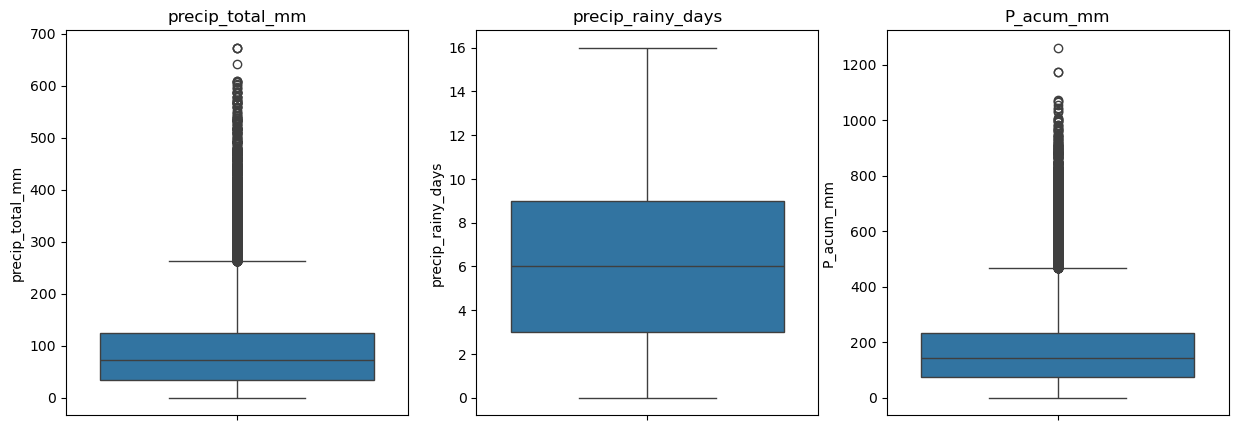

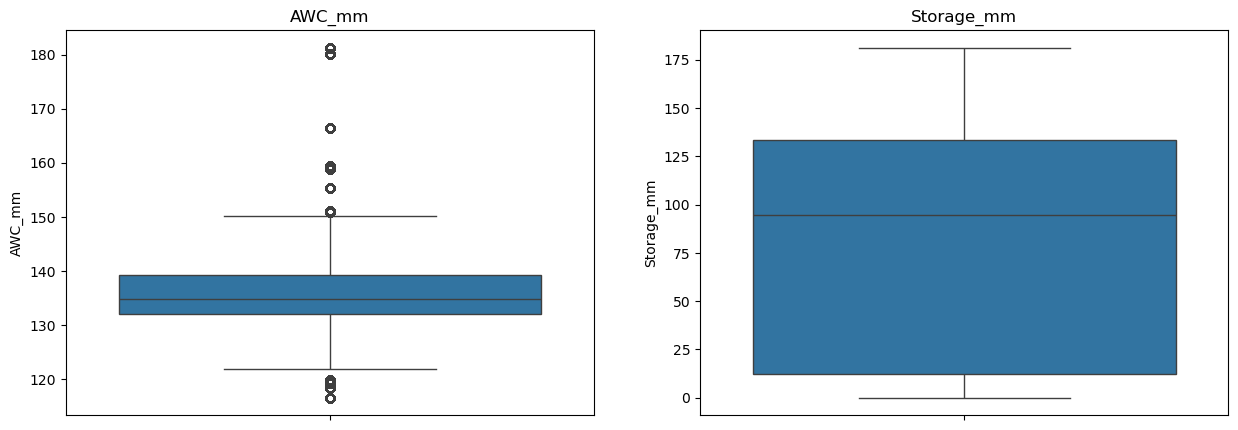

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

Presipitation = ['precip_total_mm','precip_rainy_days', 'P_acum_mm']
Soil = ['AWC_mm', 'Storage_mm']

fig, axs = plt.subplots(1,3, figsize=(15, 5))
for i, col in enumerate(Presipitation): 
    sns.boxplot(df[col],ax=axs.flatten()[i])
    axs.flatten()[i].set_title(col)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(15, 5))
for i, col in enumerate(Soil): 
    sns.boxplot(df[col],ax=axs.flatten()[i])
    axs.flatten()[i].set_title(col)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

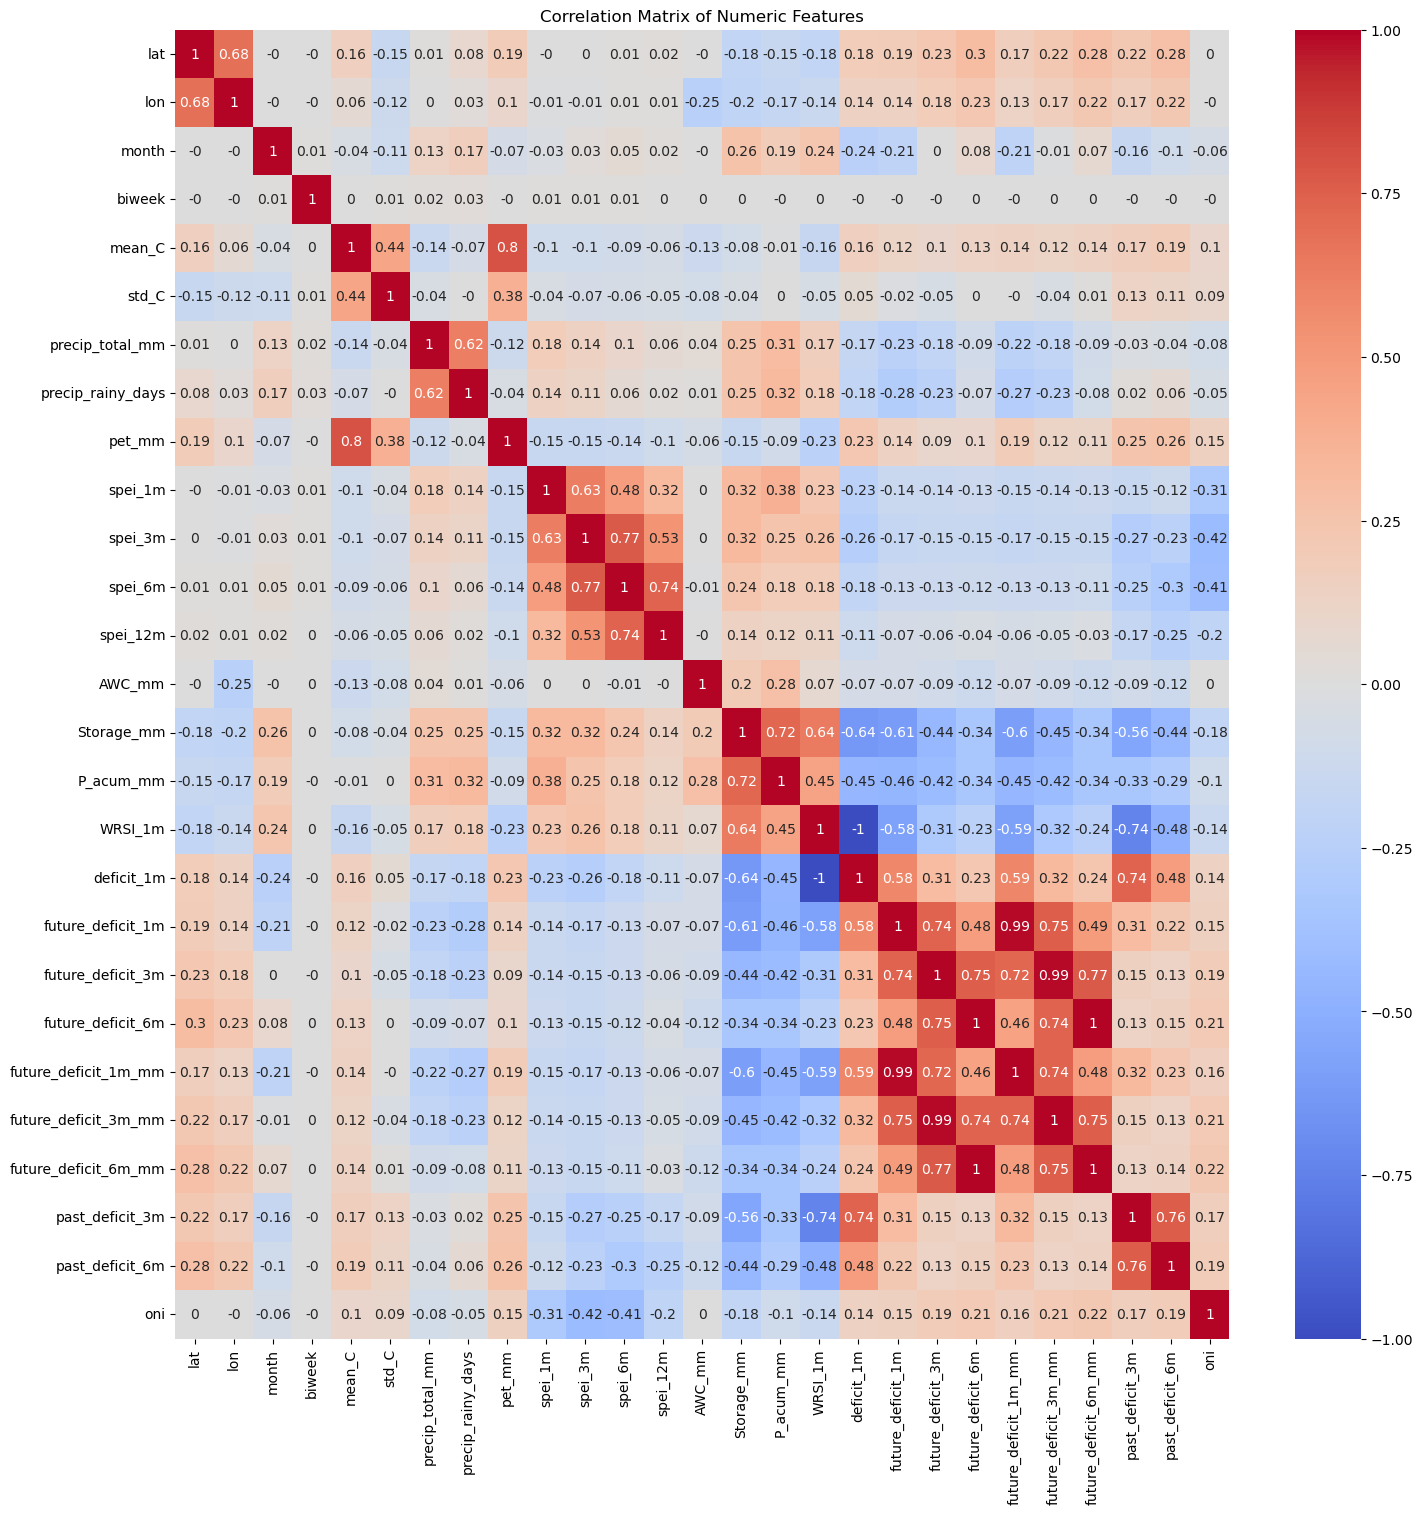

In [32]:
df_numeric_corr = df.select_dtypes(include=['number'])
corr_matrix = df_numeric_corr.corr().round(2)
plt.figure(figsize=(17, 17))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show

In [33]:
Features = [
    "month", "biweek", "mean_C", "std_C",
    "precip_total_mm", "precip_rainy_days", "pet_mm",
    "spei_1m", "spei_3m", "spei_6m", "spei_12m",
    "AWC_mm", "Storage_mm", "P_acum_mm", "WRSI_1m", "deficit_1m", "oni",
]
Targets = ["future_deficit_1m", "future_deficit_3m", "future_deficit_6m"]

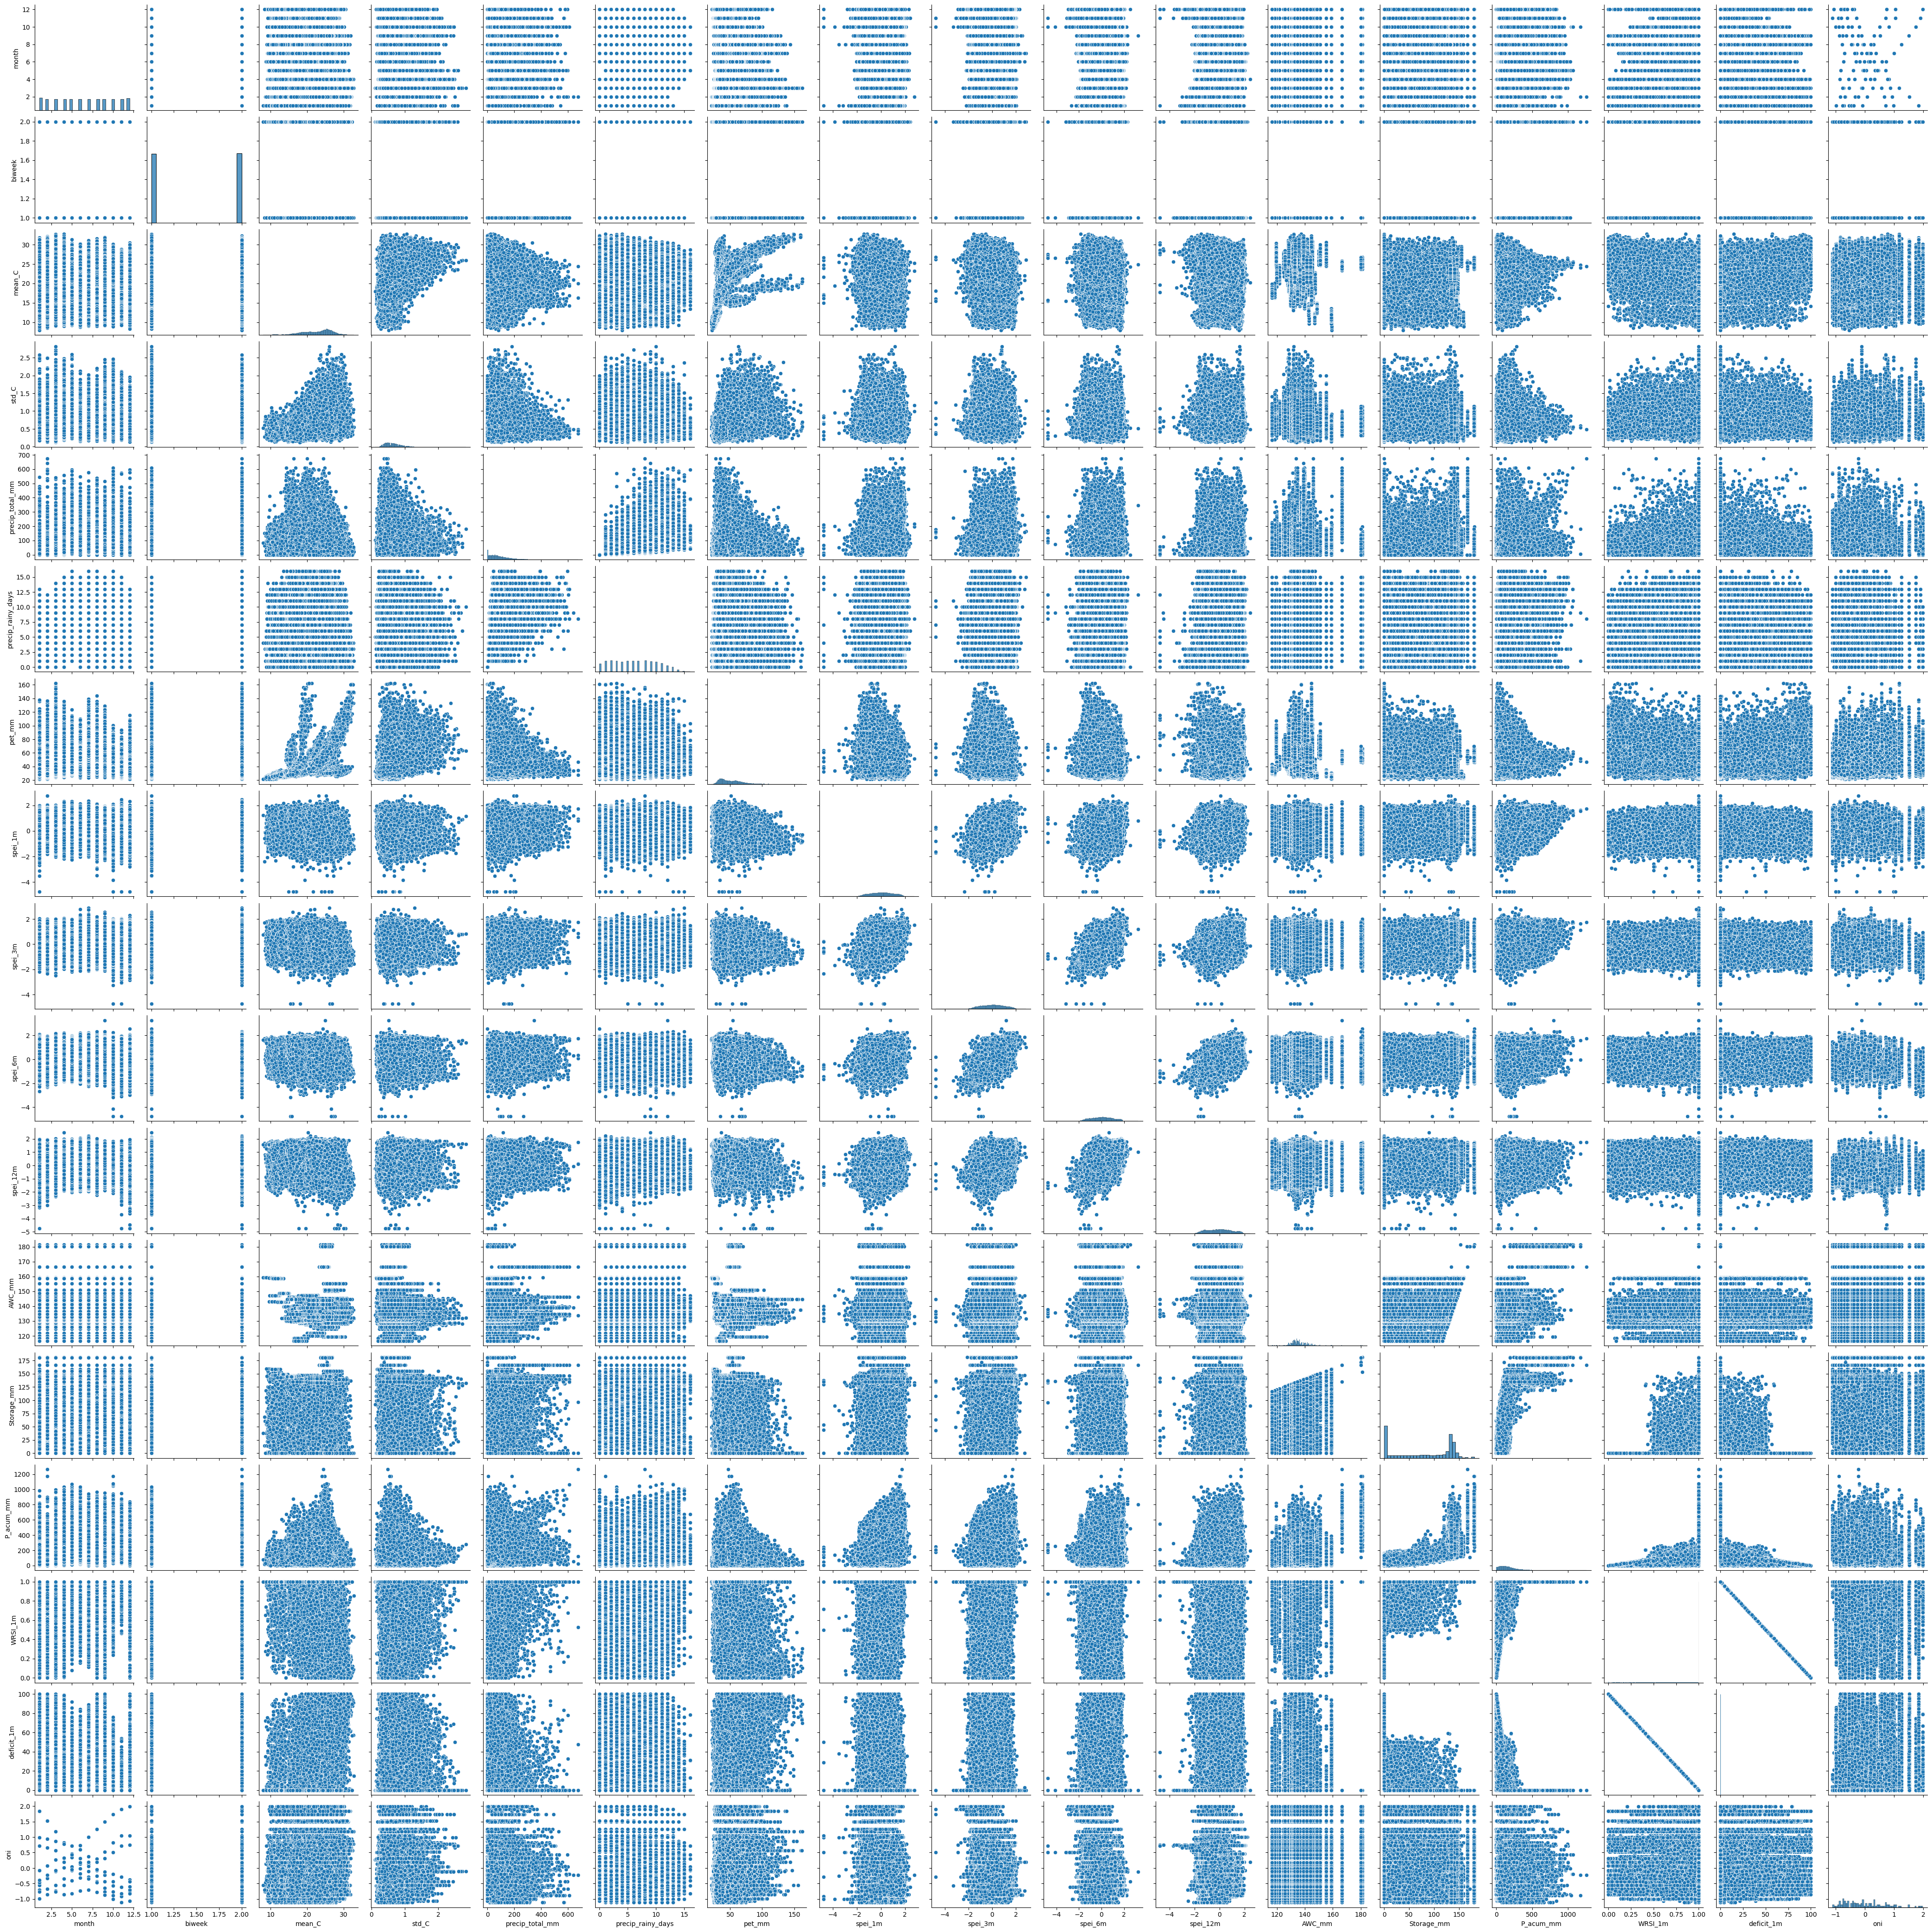

In [34]:
sns.pairplot(df[Features])